# Vectorization

In [1]:
import pandas as pd

In [2]:
df = pd.read_pickle('data/preprocessed_data.pkl')

In [3]:
df.head()

,product,complaints,tokens,tokens_str
0,credit_reporting,I have reviewed my credit report and noticed i...,"[credit, report, incorrect, information, inacc...",credit report incorrect information inaccurate...
1,credit_reporting,"Seriously, it's been months since I investigat...","[seriously, since, credit, report, information...",seriously since credit report information stil...
2,credit_reporting,SS # XXXX birthday XX/XX/year> This CFPB compl...,"[birthday, year, complaint, fill, request, pur...",birthday year complaint fill request pursuant ...
3,credit_reporting,"Upon reviewing my credit report, I have identi...","[upon, credit, report, inaccurate, need, corre...",upon credit report inaccurate need correction ...
4,credit_reporting,They are a predatory lenders who are intention...,"[predatory, intentionally, erroneous, late, ha...",predatory intentionally erroneous late hardshi...


## TF-IDF Vectorization

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
tfidf = TfidfVectorizer(max_features=5000,
                        max_df = 0.95,
                        min_df = 2,)
tfidf_matrix = tfidf.fit_transform(df['tokens_str'])
tfidf_matrix.shape

(60000, 5000)

In [12]:
tfidf_matrix.toarray()[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(5000,))

tfidf matrix is sparse which includes mostly zero in the matrix.

In [6]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:10])

mean_scores = tfidf_matrix.mean(axis=0).A1
print(mean_scores[:10])

['abandon' 'abandonment' 'abatement' 'abide' 'ability' 'able' 'abnormal'
 'abroad' 'abrupt' 'abruptly']
[2.04965940e-04 4.58962473e-05 5.29945853e-05 3.41166259e-04
 2.78876992e-03 7.73919952e-03 5.89866981e-05 1.27624699e-04
 8.35634765e-05 2.09420814e-04]


In [7]:
tfidf_mean_df = pd.DataFrame({'word' : feature_names, 'mean_scores' : mean_scores})
tfidf_mean_df = tfidf_mean_df.sort_values('mean_scores', ascending=False)
tfidf_mean_df.head(10)

,word,mean_scores
1012,credit,0.058973
40,account,0.058234
3681,report,0.037846
3115,payment,0.035208
2576,loan,0.033617
2265,information,0.032552
1073,debt,0.030772
400,bank,0.030528
597,card,0.028162
2638,make,0.026553


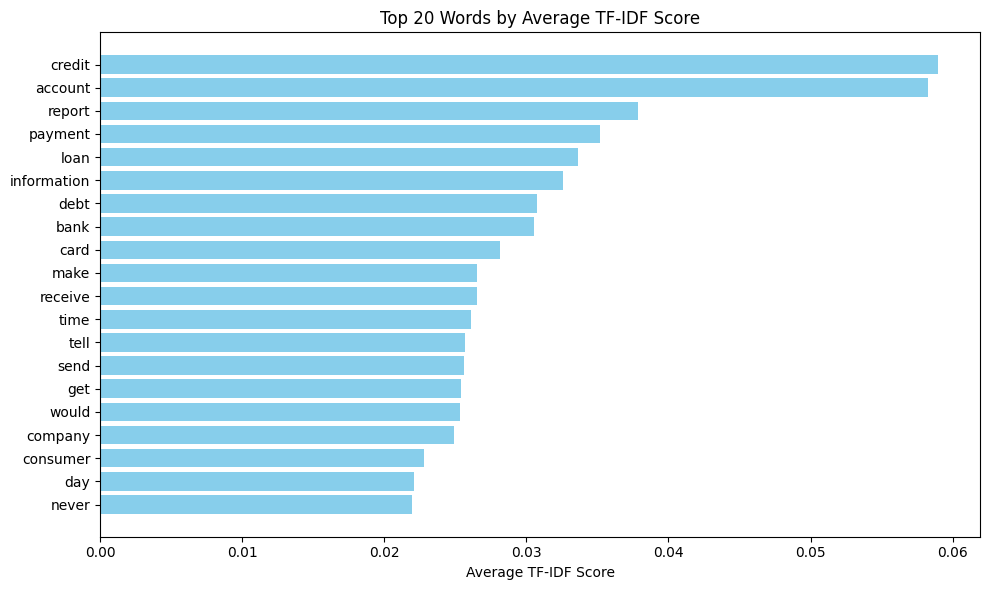

In [8]:
import matplotlib.pyplot as plt

topwords = tfidf_mean_df.head(20)
plt.figure(figsize=(10,6))
plt.barh(topwords['word'], topwords['mean_scores'], color='skyblue')
plt.xlabel('Average TF-IDF Score')
plt.title('Top 20 Words by Average TF-IDF Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('export/tfidf_topwords.png')
plt.show()

In [9]:
tfidf_matrix_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)
tfidf_matrix_df['product'] = df['product']

In [10]:
for product, group in tfidf_matrix_df.groupby('product'):
    top3 = group.drop(columns='product').mean().sort_values(ascending=False).head(3)
    print(f"\n{product}:")
    for term, score in top3.items():
        print(f"  {term}: {score:.4f}")


credit_card:
  card: 0.1224
  credit: 0.0801
  account: 0.0693

credit_reporting:
  credit: 0.1260
  report: 0.1119
  information: 0.0785

debt_collection:
  debt: 0.1375
  credit: 0.0779
  collection: 0.0660

loans:
  loan: 0.0965
  payment: 0.0588
  car: 0.0426

mortgage:
  mortgage: 0.1199
  loan: 0.0870
  payment: 0.0650

retail_banking:
  account: 0.1050
  bank: 0.0783
  fund: 0.0628


In [13]:
from scipy import sparse
# Save the sparse TF-IDF matrix
sparse.save_npz('data/tfidf_matrix.npz', tfidf_matrix)

import pickle
# Save the TF-IDF vectorizer
with open('data/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

## Word2Vec

In [14]:
from gensim.models import Word2Vec

In [15]:
from gensim.models.phrases import Phrases, Phraser

In [16]:
sent = df['tokens'].tolist()

In [17]:
phrases = Phrases(sent, min_count=30, progress_per=10000)

In [18]:
bigram = Phraser(phrases)

In [19]:
sentences = bigram[sent]

In [20]:
from collections import defaultdict
word_freq = defaultdict(int)
for sent in sentences:
    for i in sent:
        word_freq[i] += 1
len(word_freq)

15253

In [21]:
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

['account',
 'credit',
 'payment',
 'loan',
 'information',
 'would',
 'make',
 'receive',
 'bank',
 'tell']

In [22]:
import multiprocessing
cores = multiprocessing.cpu_count()
cores

10

In [23]:
w2v_model = Word2Vec(
    min_count = 20,
    window=2,
    vector_size=300,
    sample=6e-5,
    alpha=0.03,
    min_alpha=0.0007,
    negative=20,
    workers=cores-1
)

In [24]:
from time import time
t = time()

w2v_model.build_vocab(sentences, progress_per=10000)

print(f"Time to build vocab: {time() - t:.2f} seconds")

Time to build vocab: 2.57 seconds


In [25]:
t = time()

w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)
print(f"Time to train model: {time() - t:.2f} seconds")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Time to train model: 117.32 seconds


## Most similar to

In [26]:
w2v_model.wv.most_similar(positive=['credit'])

[('report', 0.6415247917175293),
 ('score', 0.504736602306366),
 ('remove', 0.5012543797492981),
 ('inaccurate', 0.47978198528289795),
 ('profile', 0.45643797516822815),
 ('negative', 0.42196545004844666),
 ('recognize_significance', 0.41255202889442444),
 ('derogatory', 0.411481648683548),
 ('negatively', 0.3909931182861328),
 ('three_major', 0.3838329315185547)]

In [27]:
w2v_model.wv.most_similar(positive=['card'])

[('debit_card', 0.6519189476966858),
 ('use', 0.4899781346321106),
 ('store', 0.48855316638946533),
 ('visa', 0.4631057381629944),
 ('open', 0.4569759964942932),
 ('activate', 0.4565230906009674),
 ('account', 0.45454463362693787),
 ('quicksilver', 0.4397624731063843),
 ('frontier', 0.43862977623939514),
 ('ending', 0.4249151647090912)]

In [28]:
w2v_model.wv.most_similar(positive=['bank'])

[('chase', 0.5870478749275208),
 ('branch', 0.5160439014434814),
 ('check', 0.5020837783813477),
 ('debit_card', 0.48187530040740967),
 ('fund', 0.4433426260948181),
 ('money', 0.4308243691921234),
 ('deposit', 0.42396214604377747),
 ('close', 0.42214351892471313),
 ('withdraw', 0.4191034734249115),
 ('banking', 0.41819506883621216)]

In [29]:
w2v_model.wv.most_similar(positive=['loan'])

[('mortgage', 0.6395035982131958),
 ('refinance', 0.5349969863891602),
 ('interest_rate', 0.5247483849525452),
 ('modification', 0.49693062901496887),
 ('lender', 0.4864460527896881),
 ('adjustable', 0.47562357783317566),
 ('rate', 0.4669555723667145),
 ('apply', 0.4416714608669281),
 ('monthly', 0.4336756765842438),
 ('repayment', 0.4168095290660858)]

In [30]:
w2v_model.wv.most_similar(positive=['mortgage'])

[('loan', 0.6395035982131958),
 ('home', 0.5053948163986206),
 ('modification', 0.48913243412971497),
 ('refinance', 0.4820839464664459),
 ('lender', 0.4607769846916199),
 ('monthly', 0.4508184790611267),
 ('escrow', 0.42930030822753906),
 ('property', 0.4263613522052765),
 ('house', 0.4137287735939026),
 ('interest_rate', 0.41198742389678955)]

In [31]:
w2v_model.wv.most_similar(positive=['debt'])

[('collection', 0.7077025175094604),
 ('validation', 0.6035459041595459),
 ('debt_collector', 0.5572410225868225),
 ('collect_debt', 0.5396583676338196),
 ('collection_agency', 0.5392369031906128),
 ('original_creditor', 0.5307319164276123),
 ('validity_debt', 0.5128560662269592),
 ('collect', 0.48372769355773926),
 ('proper_validation', 0.4673750102519989),
 ('owe', 0.4591265618801117)]

## Similarities

In [32]:
w2v_model.wv.similarity('credit', 'card')

np.float32(0.26315933)

In [33]:
w2v_model.wv.similarity('debt', 'collection')

np.float32(0.7077025)

In [34]:
w2v_model.wv.similarity('mortgage', 'loan')

np.float32(0.6395036)

In [35]:
w2v_model.wv.similarity('house', 'student')

np.float32(-0.003066903)

In [36]:
w2v_model.wv.similarity('house', 'mortgage')

np.float32(0.41372877)

## Odd-One-Out

In [37]:
w2v_model.wv.doesnt_match(['credit', 'account', 'loan'])

'loan'

In [38]:
w2v_model.wv.doesnt_match(['card', 'visa', 'mortgage'])

'mortgage'

In [39]:
w2v_model.save('models/word2vec.model')

In [40]:
w2v_model = Word2Vec.load('models/word2vec.model')
w2v_model.wv.most_similar(positive=['credit'])

[('report', 0.6415248513221741),
 ('score', 0.504736602306366),
 ('remove', 0.5012543797492981),
 ('inaccurate', 0.4797820448875427),
 ('profile', 0.45643797516822815),
 ('negative', 0.42196550965309143),
 ('recognize_significance', 0.4125520586967468),
 ('derogatory', 0.411481648683548),
 ('negatively', 0.3909931182861328),
 ('three_major', 0.38383299112319946)]